# **SEASONAL FLU VACCINE PREDICTION:**
## **FINAL NOTEBOOK.**

#### **Notebook Purpose:**
This notebook presents the complete end to end machine learning pipeline for predicting seasonal flu vaccination. It follows the CRISP-DM framework which is an iterative data science process. Each stage informs then next and findings from later stages which may cause us to revisit earlier ones.

The iterative nature of this process is deliberately shown throughout this notebook e.g evaluation rsuts inform modelling decisions and modelling decisions refernce back to data preparation choices.

#### **CRISP-DM Framework: Complete Pipeline.**



| Stage | What We Do | Section |

1. **Business Understanding** | Define stakeholder, problem statement and why ML | Section 1 |

2. **Data Understanding** | Load cleaned data, summarize key findings from analysis | Section 2 |

3. **Data Preparation** | Drop features, split, impute, scale, encode | Section 3 |

4. **Modeling** | Build baseline, tuned and ensemble models iteratively | Section 4 |

5. **Evaluation** | Evaluate models, select best, identify limitations | Section 5 |

6. **Deployment** | Recommendations for stakeholders and next steps | Section 6 |


#### **Data Source:** National 2009 H1N1 Flu Survey.


#### **Notebook Inputs:**
- `Data/Cleaned_data/cleaned_data.csv`

#### **Notebook Outputs:**
- `Data/Cleaned_data/processed_data.csv`
- Trained classification models
- Evaluation metrics and recommendations

### **BUSINESS UNDERSTANING.**

#### **Background:**

The 2009 H1N1 influenza pandemic, commonly known as "swine flu", 
swept across the world beginning in spring 2009, responsible for 
an estimated 151,000 to 575,000 deaths globally in its first year. 
In response, the United States government launched a vaccination 
campaign making H1N1 vaccines publicly available in October 2009.

In late 2009 and early 2010, the United States conducted the 
National 2009 H1N1 Flu Survey to monitor vaccination rates. 
This phone survey asked respondents whether they had received 
H1N1 and seasonal flu vaccines alongside questions about their 
backgrounds, opinions, and health behaviors.

**Note on Context:** While this dataset originates from the 2009 
US H1N1 Flu Survey, the behavioral, opinion, and demographic 
drivers of vaccine hesitancy are universal public health phenomena. 
The methodology and insights generated are directly applicable to 
the Kenyan public health context, particularly given Kenya's 
ongoing challenges with seasonal influenza vaccination uptake. 
Kenya experiences two flu seasons annually, March to May and 
October to December, aligned with the long and short rains, 
making seasonal flu vaccination a recurring and critical public 
health challenge.

#### **Stakeholders:**

This project adopts a dual - level stakeholder framework reflecting real epidemiological practice, where population-level patterns inform facility-level interventions. Our stakeholders operate within the Kenyan public health system:

**|Stakeholder | Role | What They Need |**

**|County Director of Health (CDoH) |** Responsible for public health Surveillance and community reach at County Level | Identify which communities to target for seasonal flu vaccination outreach every flu season |

**|Chief Executive Officers: Kenyatta Referral Hospital $ Mbagathi County Hospital|** Responsible for clinical interventions in public hospitals | Identify which patients to flag for additional encouragement from clinicians during consultations |


#### **Business Problem:**

Can we predict whether an individual will receive the seasonal flu vaccine based on their background, opinions, and health behaviors?

Understanding the drivers of seasonal flu vaccination uptake will allow our stakeholders to:

- **County Director of Health:** Use demographic and behavioral patterns to target community outreach programs at popualtions with consistently low vaccination rates every flu season, ensuring more effecient allocation of public health resources.

- **County Referall Hospital CEOs:** Use clinical predictors such as chronic medical conditions, doctor recommendations and health insuarance status to identify and proactively engage patients who are unlikely to vaccinate during routine clinical consultations.


#### **Why Machine Learning?**

Traditional surveys can often pinpoint and tell us vaccination rates but cannot predict future or identify at-risk individuals before vaccination campaigns begin.

A classification model allows us to :
- Predict seasonal flu vaccination likelihood for new individuals.
- Identify the most important drivers of vaccination behavior.
- Generate actionable and specific recommendations for both 
  community outreach and clinical intervention.
- Move from descriptive analysis to predictive intervention.
- Build a reusable framework that remains relevant every flu season.

#### **Project Scope:**

-  **Target Variable** : `seasonal_vaccine` only (binary: 0 = not vaccinated, 1 = vaccinated) 
-  **In Scope** : Predicting seasonal flu vaccination behavior 
-  **Out of Scope** : Predicting H1N1 vaccination, real-time prediction, causal inference 
- **Success Metric** : ROC AUC score 
- **Context** : Methodology adapted from US 2009 H1N1 Flu Survey for Kenyan public health setting 

### **DATA UNDERSTANDING:**

### **Dataset Description:**
The dataset comes from the National 2009 H1N1 Flu Survey conducted 
by the United States government. We are working with four files:

-  `training_set_features.csv` : 35 features for survey respondents | 26,707 |
-  `training_set_labels.csv` : Target variables for survey respondents | 26,707 | seasonal_vaccine only |
-  `test_set_features.csv` : Features for unseen respondents | 26,708 | 
-  `submission_format.csv` : Competition submission template | 26,708 |

My main focus is the  `training_set_features.csv` and `training_set_labels.csv`, this is because the  `test_set_features.csv` dataset has unseen data that was needed for the competition submission file while `submission_format.csv` is purely for the competition submission format.

### **Data Cleaning and Anaylsis:**

This notebook is the third and final in a series of three notebooks that form our complete data science pipeline. The full pipeline is documented as follows:

| Notebook | Purpose | Key Output |

| `01_Data_cleaning.ipynb` | Business understanding, data understanding, duplicate removal, missing values visualization | `cleaned_data.csv` |

| `02_Analysis.ipynb` | Exploratory data analysis, feature distributions, outlier detection, feature vs target analysis, correlation analysis, feature selection decisions | Visualizations and feature selection summary |

| `03_Final_notebook.ipynb` | Complete ML pipeline, modeling, evaluation and recommendations | `processed_data.csv`, trained models, stakeholder recommendations |

#### **Summary and Links to Previous Notebooks:**

#### **Data Cleaning:**

**Link:** [01_Data_cleaning.ipynb](../Notebooks/01_Data_cleaning.ipynb)

- Dataset contains **26,707 respondents** and **36 columns**
- Target variable is `seasonal_vaccine` (binary: 0 = not vaccinated, 1 = vaccinated)
- Class balance is approximately **53% not vaccinated** and **47% vaccinated** - no resampling needed
- **No duplicate rows** were found
- **30 out of 36 columns** have missing values
- Three critical columns have more than 45% missing values:
    - `employment_occupation` (50.44%)
    - `employment_industry` (49.91%)
    - `health_insurance` (45.96%)
- Missing value treatment deferred to this notebook 
  after train test split to prevent data leakage

#### **Analysis:**

**Link:** [ 02_Analysis.ipynb](02_Analysis.ipynb)

- **Opinion features** are the strongest predictors 
  of seasonal vaccination:
    - `opinion_seas_risk` (r = 0.390)
    - `doctor_recc_seasonal` (r = 0.369)
    - `opinion_seas_vacc_effective` (r = 0.362)
- **Doctor recommendation** is the second strongest 
  predictor confirming importance of clinical interventions
- **Age group** is the strongest demographic predictor — 
  65+ years: 67.4% vaccinated vs 18-34 years: 28.5%
- **Uncertainty** about vaccine side effects (Don't know) 
  is a bigger barrier than actual worry
- **14 features identified for removal** based on being 
  H1N1 specific, having negligible predictive power, 
  excessive missing values or not being transferable 
  to the Kenyan context
- **No severe multicollinearity** detected between 
  seasonal focus features
- **No true outliers** detected — flagged values are 
  legitimate survey responses


#### **Data Loading and Data Summary:**


In [1]:
#IMPORTING LIBRARIES TO BE USED DURING THE WHOLE NOTEBOOK

#Standard Libraries
import warnings
warnings.filterwarnings("ignore")

#Core Libraries
import numpy as np
import pandas as pd

#Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

#Scikit-Learn Libraries
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder
)

#Scikit-Learn Imputation Libraries
from sklearn.impute import SimpleImputer

#Scikit-learn Model Selection Libraries
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

#Scikit-Learn Models
from sklearn.linear_model import (
    LogisticRegression,
    Ridge,
    Lasso
)

#Decision Tree Models
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Scikit-Learn Pipelines
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

#Ensmble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

#Scikit-Learn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

#Statsmodels Libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Display Settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

#Random seed for reproducibility across all models and splits

RANDOM_STATE = 42

print ("All Libraries are imported successfuly and ready to use")



All Libraries are imported successfuly and ready to use


In [2]:
#Loading and viewing the Cleaned data:

cleaned_path = "../Data/Cleaned_data/"
images_path = "../Images/"

df = pd.read_csv(
    cleaned_path + "cleaned_data.csv",
    index_col="respondent_id"
)

print(f" Cleaned data loaded successfully")
print(f"  Shape : {df.shape}")
df.head(5)

 Cleaned data loaded successfully
  Shape : (26707, 36)


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0


In [3]:
#Quick data Understanding summary:

print("Data Understanding Summary")
print(f"Rows              : {df.shape[0]}")
print(f"Columns           : {df.shape[1]}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicates        : {df.duplicated().sum()}")
print(f"\nClass Balance:")
print(f"Not Vaccinated (0): {(df['seasonal_vaccine']==0).sum()} ({(df['seasonal_vaccine']==0).mean():.1%})")
print(f"Vaccinated     (1): {(df['seasonal_vaccine']==1).sum()} ({(df['seasonal_vaccine']==1).mean():.1%})")

Data Understanding Summary
Rows              : 26707
Columns           : 36
Missing Values    : 60762
Duplicates        : 0

Class Balance:
Not Vaccinated (0): 14272 (53.4%)
Vaccinated     (1): 12435 (46.6%)


### **DATA PREPARATION:**


In this section we prepare our cleaned data for machine 
learning modeling. This section is the most critical in 
terms of preventing data leakage and ensuring our model 
performance on test data realistically represents how it 
would perform on truly unseen data.

### Why Order Matters
The order of operations in this section is deliberate 
and follows best practices for machine learning:
```
Load Cleaned Data
        ↓
Drop Irrelevant Features        ← safe on full dataset
                                   no statistics calculated
                                   just removing columns
        ↓
Define Features and Target      ← separate X and y
        ↓
Train Test Split                ← split BEFORE any transformation
                                   test set is locked away
                                   never used for fitting
        ↓
Visualize Missing Values        ← on training set only
Before Treatment                   just visualization
                                   no changes to data
        ↓
Preprocessing Pipeline          ← fit on training set ONLY
  ├── Numeric Features              then transform both
  │   ├── Median Imputation         train and test sets
  │   └── Standard Scaling          separately
  └── Categorical Features
      ├── Most Frequent Imputation
      └── One Hot Encoding
        ↓
Visualize Missing Values        ← confirm no missing values
After Treatment                    remain after imputation
        ↓
Save Processed Data             ← save for reference
```

### Key Data Leakage Prevention Decisions

| Decision | Reason |

| Drop columns before splitting | Dropping columns does not involve calculating any statistics from the data so it is safe to do on the full dataset |

| Split before imputing | If we imputed on the full dataset the test set values would influence the median used to fill training data — that is leakage |

| Split before scaling | If we scaled on the full dataset the test set values would influence the mean and standard deviation used to scale training data — that is leakage |

| Split before encoding | If we encoded on the full dataset the test set categories would influence the encoding applied to training data — that is leakage |

| Fit preprocessor on train only | The preprocessor learns statistics from training data only then applies those same statistics to transform the test set |

| Transform test with train statistics | The test set is transformed using the median, mean, standard deviation and categories learned from the training set only |

### What Goes Into the Pipeline

**Numeric Features:**
- `SimpleImputer(strategy="median")` - median imputation 
  is preferred over mean as it is robust to the skewed 
  distributions and outliers observed in our numeric 
  features during analysis i.e. if most peaople scored 4 on opinion_seas_risk and a few scored very low, the mean would be pulled down by those low scores giving us a misleading fill value. The median ignores those extremes and gives us the true middle value.

  And for our categorical values most frequent imputation preserves the natural distribution by filing missing values with the most common category rather than introducing a new category. E.g. for somthing like employment status the safest assumption is that amissing value most likely belongs to the most common category which can be employes, unemployed or not in Labour force.

- `StandardScaler()` - scales features to zero mean and 
  unit variance, required for distance based models like 
  Logistic Regression with regularization

**Categorical Features:**
- `SimpleImputer(strategy="most_frequent")` - most frequent 
  imputation preserves the natural distribution of 
  categorical features by filling missing values with 
  the most common category rather than introducing 
  a new artificial category
- `OneHotEncoder(handle_unknown="ignore")` - converts 
  categorical variables to binary columns, one per 
  category. handle_unknown="ignore" ensures unseen 
  categories in test set do not cause errors

#### **Drop Irrelevant Features:**
Based on our analysis notebook findings we drop features 
that are either:
- H1N1 specific and out of scope
- Have negligible predictive power
- Have too many missing values
- Contain random string identifiers
- Not transferable to the Kenyan context

In [4]:
#Drop Irrelevant columns that won't be used in modelling

# Features to drop based on analysis notebook findings
cols_to_drop = [
    "h1n1_concern",
    "h1n1_knowledge",
    "doctor_recc_h1n1",
    "opinion_h1n1_vacc_effective",
    "opinion_h1n1_risk",
    "opinion_h1n1_sick_from_vacc",
    "behavioral_antiviral_meds",
    "child_under_6_months",
    "hhs_geo_region",
    "employment_industry",
    "employment_occupation",
    "census_msa",
    "race",
    "household_adults"
]

# Defensive drop - only drop columns that exist also so that an error doesn't occur when rerunning these cells later.
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f" Dropped {len(cols_to_drop)} irrelevant features")
print(f"  Remaining columns : {df.shape[1]}")
print(f"  Remaining shape   : {df.shape}")

 Dropped 14 irrelevant features
  Remaining columns : 22
  Remaining shape   : (26707, 22)


#### **Define features and Target:**


In [5]:
#Defining Features and Target Variable:

# Separate features and target
X = df.drop(columns=["seasonal_vaccine"])
y = df["seasonal_vaccine"]

# Separate numeric and categorical columns
# Exclude target variable to prevent data leakage during preprocessing
numeric_features = X.select_dtypes(
    include=["float64", "int64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(f" Features and target defined")
print(f"  Total Features       : {X.shape[1]}")
print(f"  Numeric Features     : {len(numeric_features)}")
for col in numeric_features:
    print(f"    - {col}")
print(f"\n  Categorical Features : {len(categorical_features)}")
for col in categorical_features:
    print(f"    - {col}")
print(f"\n  Target               : seasonal_vaccine")

 Features and target defined
  Total Features       : 21
  Numeric Features     : 14
    - behavioral_avoidance
    - behavioral_face_mask
    - behavioral_wash_hands
    - behavioral_large_gatherings
    - behavioral_outside_home
    - behavioral_touch_face
    - doctor_recc_seasonal
    - chronic_med_condition
    - health_worker
    - health_insurance
    - opinion_seas_vacc_effective
    - opinion_seas_risk
    - opinion_seas_sick_from_vacc
    - household_children

  Categorical Features : 7
    - age_group
    - education
    - sex
    - income_poverty
    - marital_status
    - rent_or_own
    - employment_status

  Target               : seasonal_vaccine


#### **Train Test Split:**

I split the data before any imputation, scaling or encoding to prevent data leakage. I used stratified splitting to maintain class balance in both sets where a test size of 20% gives 5,341 samples for evaluation which is sufficient for extensive modell assesment.

In [6]:
#Split data and ensured to stratify on target to mainatin class balance.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y)

#Stratification above was done to maintain a balanced class

print("Train test split completed")
print(f"\n  Training set   : {X_train.shape}")
print(f"  Test set       : {X_test.shape}")
print(f"\n  Class Balance Check:")
print(f"  Train - Not Vaccinated : {(y_train==0).sum()} ({(y_train==0).mean():.1%})")
print(f"  Train - Vaccinated     : {(y_train==1).sum()} ({(y_train==1).mean():.1%})")
print(f"  Test  - Not Vaccinated : {(y_test==0).sum()} ({(y_test==0).mean():.1%})")
print(f"  Test  - Vaccinated     : {(y_test==1).sum()} ({(y_test==1).mean():.1%})")

Train test split completed

  Training set   : (21365, 21)
  Test set       : (5342, 21)

  Class Balance Check:
  Train - Not Vaccinated : 11417 (53.4%)
  Train - Vaccinated     : 9948 (46.6%)
  Test  - Not Vaccinated : 2855 (53.4%)
  Test  - Vaccinated     : 2487 (46.6%)


#### **Missing Values - Before Treatment**

I visualized missing values in the training set only. This confirmed missing values exist before imputation and demonstrates I am treating train and test separately to prevent data leakage.

Columns with missing values in training set: 19


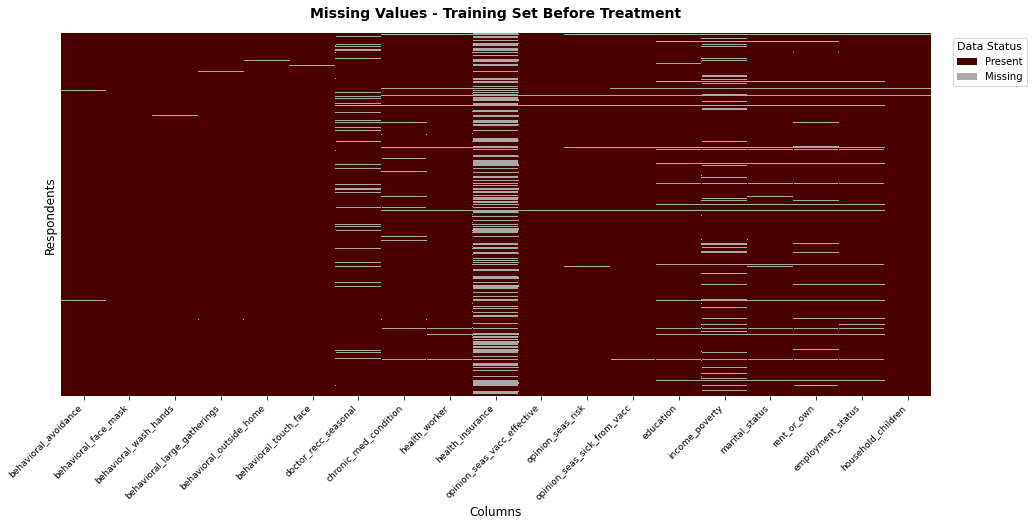

In [7]:
#Missing Values Heatmap
#Before Treatment

custom_cmap = ListedColormap(["#4A0000", "#A9A9A9"])

# Show missing values in training set only
missing_cols = X_train.columns[X_train.isnull().any()].tolist()

print(f"Columns with missing values in training set: {len(missing_cols)}")

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    X_train[missing_cols].isnull(),
    yticklabels=False,
    cbar=False,
    cmap=custom_cmap,
    ax=ax
)

ax.set_title(
    "Missing Values - Training Set Before Treatment",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Columns", fontsize=12)
ax.set_ylabel("Respondents", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=9)

legend_elements = [
    Patch(facecolor="#4A0000", label="Present"),
    Patch(facecolor="#A9A9A9", label="Missing")
]
ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title="Data Status",
    title_fontsize=11,
    frameon=True
)

plt.subplots_adjust(bottom=0.25, right=0.88)
plt.savefig(images_path + "missing_values_train_before.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### **Preprocessing:**

I built a single preprocessing pipeline that:

- Imputes missing numeric values using median strategy
- Imputes missing categorical values using most frequent strategy
- Scales numeric features using StandardScaler
- Encodes categorical features using OneHotEncoder
- Fits ONLY on training data and transforms both 
  train and test sets to prevent data leakage

In [8]:
#Preprocessing pipeline

# Numeric pipeline - impute missing values then scale: used the median impuatation as its robust to outliers
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline - impute missing values then encode used the most frequent imputation startegy
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse = False))
])

# Combine numeric and categorical pipelines
# Fit on training data only to prevent data leakage
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit on training data only and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f" Preprocessing pipeline completed")
print(f"  X_train_processed shape : {X_train_processed.shape}")
print(f"  X_test_processed shape  : {X_test_processed.shape}")

 Preprocessing pipeline completed
  X_train_processed shape : (21365, 35)
  X_test_processed shape  : (5342, 35)


#### **Missing Values - After Treatment:**

✓ Missing values after treatment: 0


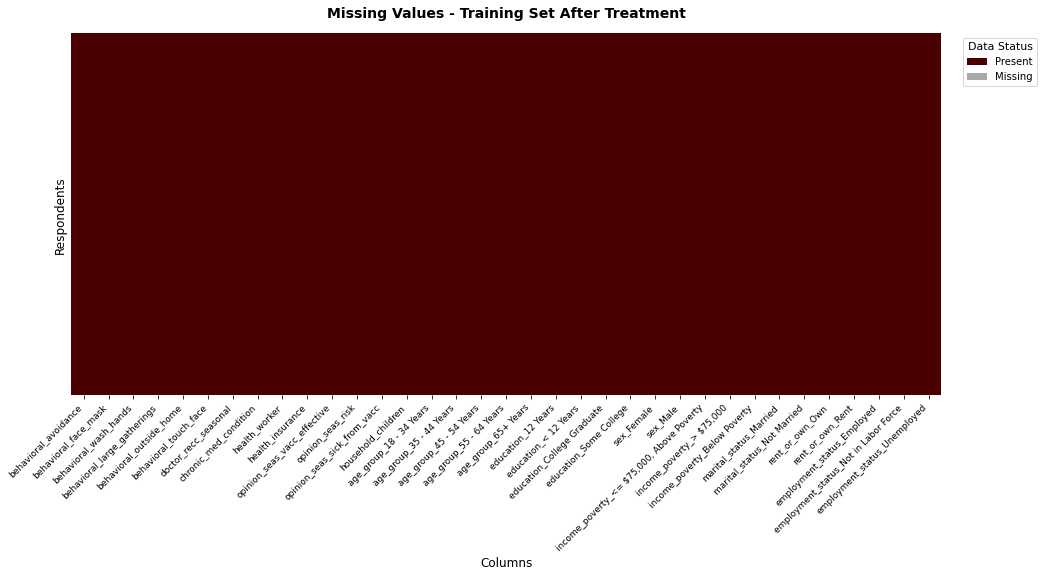

In [9]:
#Missing Value heatmap after treatment

# Get feature names manually(Because i am using an older version of sci-kit learn)
numeric_feature_names = numeric_features

# Get categorical feature names after one hot encoding
categorical_feature_names = preprocessor\
    .named_transformers_["categorical"]\
    .named_steps["encoder"]\
    .get_feature_names(categorical_features)\
    .tolist()

# Combine all feature names
all_feature_names = numeric_feature_names + categorical_feature_names

# Convert processed array back to dataframe for visualization
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=all_feature_names
)

# Confirm no missing values remain
missing_after = X_train_df.isnull().sum().sum()
print(f"✓ Missing values after treatment: {missing_after}")

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    X_train_df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap=custom_cmap,
    ax=ax
)

ax.set_title(
    "Missing Values - Training Set After Treatment",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Columns", fontsize=12)
ax.set_ylabel("Respondents", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=9)

ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title="Data Status",
    title_fontsize=11,
    frameon=True
)

plt.subplots_adjust(bottom=0.25, right=0.88)
plt.savefig(images_path + "missing_values_train_after.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### **Save Processed Data:**


In [10]:
#Saving the Processed data to the Cleaned_data folder

X_train_df["seasonal_vaccine"] = y_train.values
X_train_df.to_csv(
    cleaned_path + "processed_data.csv",
    index=False
)

print(f" Processed data saved successfully")
print(f"  Location : {cleaned_path}processed_data.csv")
print(f"  Shape    : {X_train_df.shape}")


 Processed data saved successfully
  Location : ../Data/Cleaned_data/processed_data.csv
  Shape    : (21365, 36)


### **MODELING.**

I follow an iterative modeling approach as required by the CRISP-DM framework. 

Modeling approach:

1. **Baseline Model** — Logistic Regression (simple, interpretable)
2. **Tuned Model** — Logistic Regression + Ridge (L2 regularization)
3. **Tuned Model** — Logistic Regression + Lasso (L1 regularization)
4. **Nonparametric Model** — Decision Tree
5. **Ensemble Model** — Random Forest

Each model will be evaluated using a single reusable evalutaion function and results compared at the end to select the best model for our business problem

#### **Evaluation Function:**

A single reusable evaluation function is defined here 
and used consistently across all models. This ensures 
fair comparison between models and avoids repetitive code.

Our primary metric is **ROC AUC** because:
- It measures the model's ability to distinguish between 
  vaccinated and unvaccinated individuals
- It is threshold independent - works well for both 
  classes regardless of the decision boundary
- It is appropriate for our balanced dataset
- It is the standard metric for binary classification 
  in public health research

In [11]:

# SINGLE REUSABLE EVALUATION FUNCTION


def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Single reusable function to evaluate all classification models.
    
    Parameters:
    -----------
    model_name : str
        Name of the model being evaluated
    y_true : array
        True target values
    y_pred : array
        Predicted target values
    y_prob : array
        Predicted probabilities for positive class
        
    Returns:
    --------
    dict : Dictionary of evaluation metrics
    """
    # Calculate all metrics
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    roc_auc   = roc_auc_score(y_true, y_prob)
    
    # Print results
    print(f"\n{'='*50}")
    print(f"Model     : {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC AUC   : {roc_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Vaccinated", "Vaccinated"]
    ))
    
    # Plot confusion matrix using seaborn
    # Compatible with older scikit-learn versions
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="RdYlGn",
        xticklabels=["Not Vaccinated", "Vaccinated"],
        yticklabels=["Not Vaccinated", "Vaccinated"],
        ax=ax
    )
    ax.set_title(
        f"Confusion Matrix - {model_name}",
        fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(
        images_path + f"confusion_matrix_{model_name.replace(' ', '_')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    
    # Return metrics as dictionary for comparison later
    return {
        "Model"    : model_name,
        "Accuracy" : round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall"   : round(recall, 4),
        "F1 Score" : round(f1, 4),
        "ROC AUC"  : round(roc_auc, 4)
    }

print("✓ Evaluation function defined successfully!")

✓ Evaluation function defined successfully!


#### **Baseline Model : Logistic Regression.**

Our baseline model is Logistic Regression because:

- It is the standard starting point for binary classification problems
- It is simple and highly interpretable
- It provides probability estimates directly
- Its coefficients directly show the direction and 
  magnitude of each feature's influence
- It is appropriate for our balanced dataset

We use default hyperparameters for the baseline to 
establish a performance benchmark before tuning.

In [12]:
# Initialize results list to store all model results for comparison
all_results = []


Model     : Logistic Regression Baseline
  Accuracy  : 0.7756
  Precision : 0.7727
  Recall    : 0.7338
  F1 Score  : 0.7527
  ROC AUC   : 0.8506

Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.78      0.81      0.79      2855
    Vaccinated       0.77      0.73      0.75      2487

      accuracy                           0.78      5342
     macro avg       0.78      0.77      0.77      5342
  weighted avg       0.78      0.78      0.78      5342



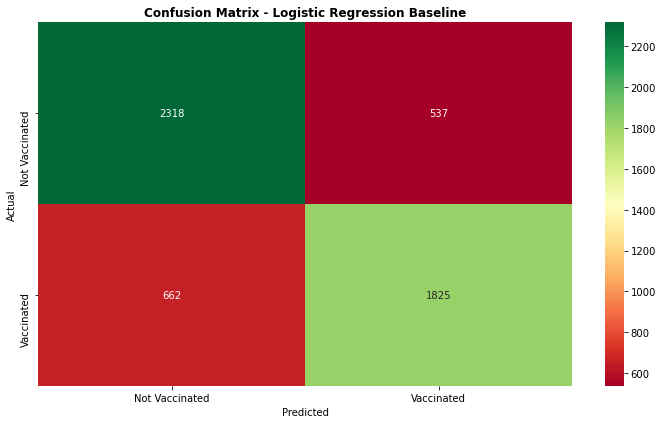

Baseline model complete!


In [13]:
#MODEL 1 AND BASELINE MODEL: LOGISTIC REGRESSION

# Build pipeline with preprocessing and logistic regression
# Using default hyperparameters for baseline
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000    # Increase iterations to ensure convergence
    ))
])

# Fit on training data only
baseline_pipeline.fit(X_train, y_train)

# Predict on test data
y_pred_baseline = baseline_pipeline.predict(X_test)

# Get probability estimates for ROC AUC
# [:, 1] gets probability of positive class (vaccinated)
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

# Evaluate using our reusable function
baseline_results = evaluate_model(
    "Logistic Regression Baseline",
    y_test,
    y_pred_baseline,
    y_prob_baseline
)

print("Baseline model complete!")

#### **Tuned Model : Logistic Regression with Ridge (L2)**

Involves tuning our baseline model by adding Ridge regularization.

**Why Ridge regularization?**

- Our dataset has many features after one hot encoding
- Ridge shrinks all coefficients towards zero reducing 
  overfitting without removing any features
- We tune the C parameter which controls regularization 
  strength — smaller C means stronger regularization
- We use GridSearchCV to find the optimal C value

Logistic Regression with Ridge (L2) 
 Best C value : 0.1
  Best ROC AUC : 0.8472

Model     : Logistic Regression Ridge
  Accuracy  : 0.7750
  Precision : 0.7721
  Recall    : 0.7330
  F1 Score  : 0.7521
  ROC AUC   : 0.8506

Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.78      0.81      0.79      2855
    Vaccinated       0.77      0.73      0.75      2487

      accuracy                           0.77      5342
     macro avg       0.77      0.77      0.77      5342
  weighted avg       0.77      0.77      0.77      5342



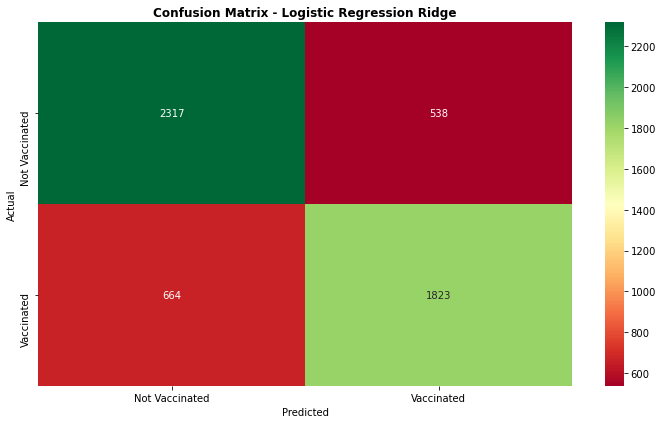

In [14]:
#Ridge Regression with Hyperparameter tuning


# Define reusable function for regularized logistic regression
def build_logistic_pipeline(penalty, C_values):
    """
    Reusable function to build and tune logistic regression
    pipeline with either Ridge (L2) or Lasso (L1) regularization.
    
    Parameters:
    -----------
    penalty : str
        Regularization type - 'l1' or 'l2'
    C_values : list
        List of C values to search over
        
    Returns:
    --------
    best_pipeline : fitted pipeline with best hyperparameters
    """
    # Build pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            penalty=penalty,
            random_state=RANDOM_STATE,
            max_iter=1000,
            solver="saga"    # Saga solver supports both L1 and L2
        ))
    ])
    
    # Define hyperparameter grid
    param_grid = {
        "classifier__C": C_values
    }
    
    # GridSearchCV to find best C value
    # cv=5 means 5 fold cross validation
    # scoring="roc_auc" aligns with our success metric
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1    # Use all available cores
    )
    
    # Fit on training data only
    grid_search.fit(X_train, y_train)
    
    print(f" Best C value : {grid_search.best_params_['classifier__C']}")
    print(f"  Best ROC AUC : {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_

# Build and tune Ridge model
print("Logistic Regression with Ridge (L2) ")
ridge_pipeline = build_logistic_pipeline(
    penalty="l2",
    C_values=[0.001, 0.01, 0.1, 1, 10, 100]
)

# Predict on test data
y_pred_ridge = ridge_pipeline.predict(X_test)
y_prob_ridge = ridge_pipeline.predict_proba(X_test)[:, 1]

# Evaluate using our reusable function
ridge_results = evaluate_model(
    "Logistic Regression Ridge",
    y_test,
    y_pred_ridge,
    y_prob_ridge
)

#### **Tuned Model : Logistic Regression with Lasso (L1)**

We now try Lasso regularization on our baseline model.

**Why Lasso regularization?**

- Unlike Ridge, Lasso can shrink coefficients to exactly 
  zero effectively removing features from the model
- This gives us automatic feature selection
- Useful for identifying the most important features
- We use the same reusable function from Ridge model

 Logistic Regression with Lasso (L1) 
 Best C value : 1
  Best ROC AUC : 0.8471

Model     : Logistic Regression Lasso
  Accuracy  : 0.7756
  Precision : 0.7727
  Recall    : 0.7338
  F1 Score  : 0.7527
  ROC AUC   : 0.8506

Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.78      0.81      0.79      2855
    Vaccinated       0.77      0.73      0.75      2487

      accuracy                           0.78      5342
     macro avg       0.78      0.77      0.77      5342
  weighted avg       0.78      0.78      0.78      5342



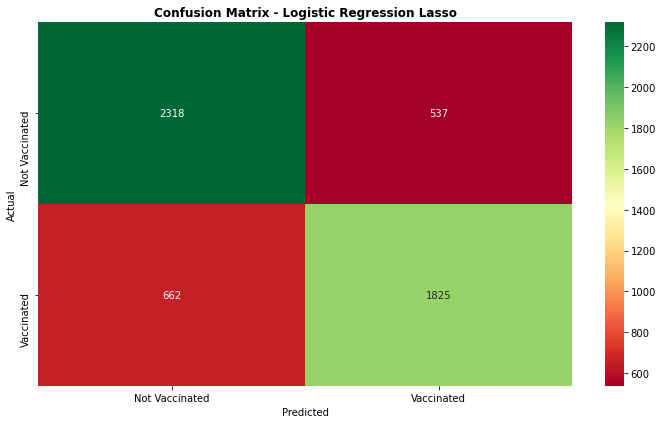

In [15]:
#Lasso Regression/Regulirazation with Hyperparameter tuning

# Build and tune Lasso model using same reusable function
print(" Logistic Regression with Lasso (L1) ")
lasso_pipeline = build_logistic_pipeline(
    penalty="l1",
    C_values=[0.001, 0.01, 0.1, 1, 10, 100]
)

# Predict on test data
y_pred_lasso = lasso_pipeline.predict(X_test)
y_prob_lasso = lasso_pipeline.predict_proba(X_test)[:, 1]

# Evaluate using our reusable function
lasso_results = evaluate_model(
    "Logistic Regression Lasso",
    y_test,
    y_pred_lasso,
    y_prob_lasso
)

#### **Nonparametric Model : Decision Tree**
Implemented a Decision Tree classifier as my second model

**Why Decision Tree?**

- Nonparametric - makes no assumptions about data distribution
- Captures non-linear relationships between features and target
- Highly interpretable  we can visualize exactly how 
  decisions are made
- Good comparison point against our linear models
- We tune max_depth to prevent overfitting

**What is a Decision Tree?**

A Decision Tree splits the data at each node based on 
the feature that best separates vaccinated from 
unvaccinated individuals. It continues splitting until 
it reaches a stopping criterion such as maximum depth.
Each leaf node gives a final prediction.

 Best parameters : {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
  Best ROC AUC    : 0.8308

Model     : Decision Tree
  Accuracy  : 0.7654
  Precision : 0.7737
  Recall    : 0.7012
  F1 Score  : 0.7357
  ROC AUC   : 0.8356

Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.76      0.82      0.79      2855
    Vaccinated       0.77      0.70      0.74      2487

      accuracy                           0.77      5342
     macro avg       0.77      0.76      0.76      5342
  weighted avg       0.77      0.77      0.76      5342



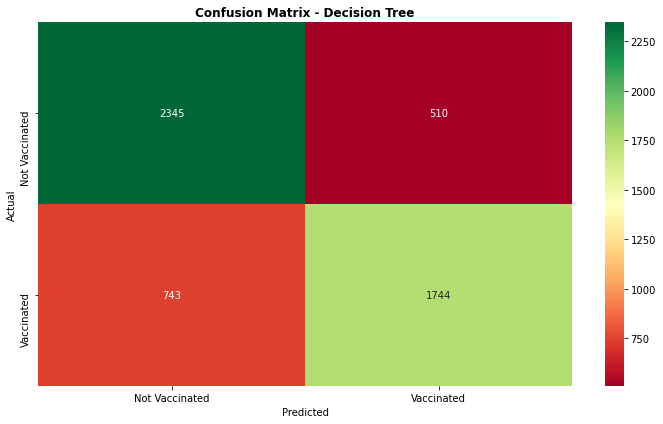

In [16]:
#Secondary Model : Decision Tree with Hyperparameter Tuning

# Build decision tree pipeline
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

# Tune max_depth using GridSearchCV
param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit on training data only
grid_search_dt.fit(X_train, y_train)

print(f" Best parameters : {grid_search_dt.best_params_}")
print(f"  Best ROC AUC    : {grid_search_dt.best_score_:.4f}")

# Get best pipeline
dt_best_pipeline = grid_search_dt.best_estimator_

# Predict on test data
y_pred_dt = dt_best_pipeline.predict(X_test)
y_prob_dt = dt_best_pipeline.predict_proba(X_test)[:, 1]

# Evaluate using our reusable function
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt
)

#### **Ensemble Model : Random Forest**

Our final model is a Random Forest classifier.

**Why Random Forest?**

- Ensemble method — combines multiple decision trees
- Each tree is trained on a random subset of data 
  and features reducing overfitting
- Generally outperforms single decision trees
- Provides feature importance scores
- Robust to outliers and missing values
- We tune n_estimators and max_depth

**How Random Forest works:**

- Builds multiple decision trees on random subsets of 
  training data (bagging)
- Each tree uses a random subset of features at each split
- Final prediction is the majority vote across all trees
- More trees generally means better performance but 
  longer training time

✓ Best parameters : {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
  Best ROC AUC    : 0.8474

Model     : Random Forest
  Accuracy  : 0.7772
  Precision : 0.7851
  Recall    : 0.7181
  F1 Score  : 0.7501
  ROC AUC   : 0.8518

Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.77      0.83      0.80      2855
    Vaccinated       0.79      0.72      0.75      2487

      accuracy                           0.78      5342
     macro avg       0.78      0.77      0.77      5342
  weighted avg       0.78      0.78      0.78      5342



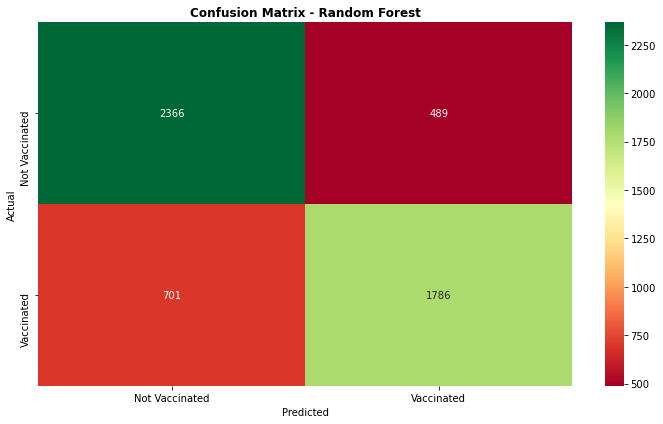

In [17]:


# Build random forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Tune hyperparameters using GridSearchCV
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit on training data only
grid_search_rf.fit(X_train, y_train)

print(f"✓ Best parameters : {grid_search_rf.best_params_}")
print(f"  Best ROC AUC    : {grid_search_rf.best_score_:.4f}")

# Get best pipeline
rf_best_pipeline = grid_search_rf.best_estimator_

# Predict on test data
y_pred_rf = rf_best_pipeline.predict(X_test)
y_prob_rf = rf_best_pipeline.predict_proba(X_test)[:, 1]

# Evaluate using our reusable function
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

#### **Model Comparison**

Model Comparison
                              Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                                       
Random Forest                   0.7772     0.7851  0.7181    0.7501   0.8518
Logistic Regression Baseline    0.7756     0.7727  0.7338    0.7527   0.8506
Logistic Regression Ridge       0.7750     0.7721  0.7330    0.7521   0.8506
Logistic Regression Lasso       0.7756     0.7727  0.7338    0.7527   0.8506
Decision Tree                   0.7654     0.7737  0.7012    0.7357   0.8356


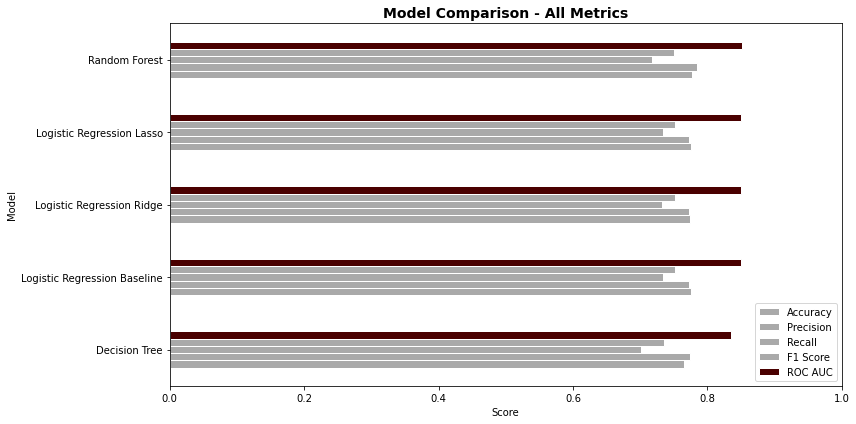

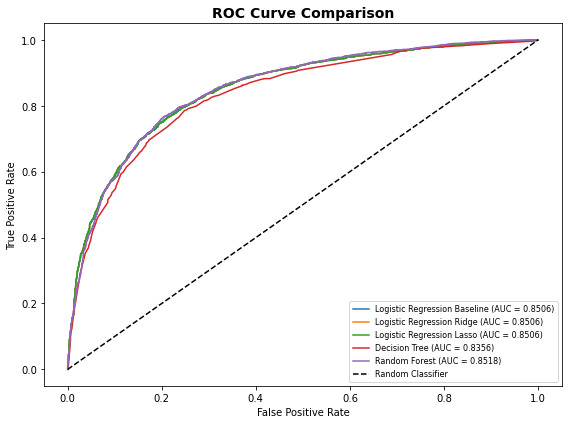

In [18]:


# Combine all results into one dataframe
results_df = pd.DataFrame([
    baseline_results,
    ridge_results,
    lasso_results,
    dt_results,
    rf_results
])

# Set model name as index
results_df = results_df.set_index("Model")

# Display results sorted by ROC AUC
print("Model Comparison")
print(results_df.sort_values("ROC AUC", ascending=False))

# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))

results_df.sort_values("ROC AUC", ascending=True).plot(
    kind="barh",
    ax=ax,
    color=["#A9A9A9", "#A9A9A9", "#A9A9A9", "#A9A9A9", "#4A0000"],
    edgecolor="white"
)

ax.set_title(
    "Model Comparison - All Metrics",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Score")
ax.set_ylabel("Model")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(images_path + "model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ROC Curve comparison
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve for each model
for name, y_prob in [
    ("Logistic Regression Baseline", y_prob_baseline),
    ("Logistic Regression Ridge", y_prob_ridge),
    ("Logistic Regression Lasso", y_prob_lasso),
    ("Decision Tree", y_prob_dt),
    ("Random Forest", y_prob_rf)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# Plot random classifier line
ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax.set_title("ROC Curve Comparison",
             fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(images_path + "roc_curve_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# Debug - check which variables are defined, i was having an issue where i had not defined y_prob_baseline properly in the logistic regression model.
variables = [
    "y_prob_baseline",
    "y_prob_ridge", 
    "y_prob_lasso",
    "y_prob_dt",
    "y_prob_rf"
]

for var in variables:
    try:
        val = eval(var)
        print(f"✓ {var} is defined")
    except NameError:
        print(f"✗ {var} is NOT defined")

✓ y_prob_baseline is defined
✓ y_prob_ridge is defined
✓ y_prob_lasso is defined
✓ y_prob_dt is defined
✓ y_prob_rf is defined


#### **ROC Curve Comparison:**

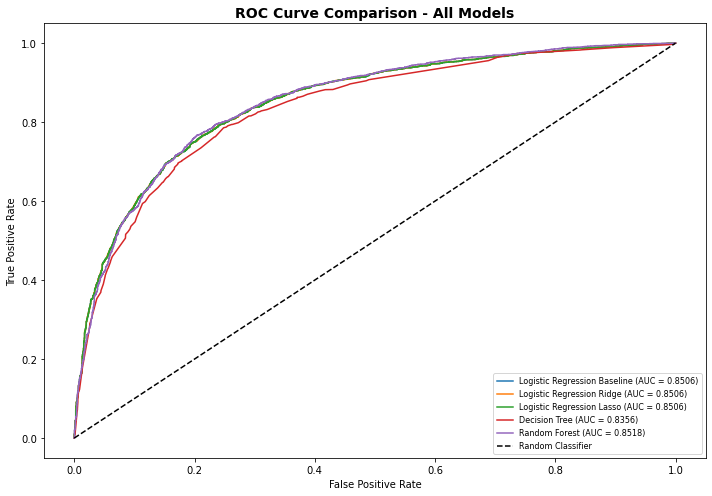

In [20]:
#ROC Curve Comparison

# Initialize results list to store all model results for comparison
all_results = []

fig, ax = plt.subplots(figsize=(10, 7))

# Plot ROC curve for each model
for name, y_prob in [
    ("Logistic Regression Baseline", y_prob_baseline),
    ("Logistic Regression Ridge",    y_prob_ridge),
    ("Logistic Regression Lasso",    y_prob_lasso),
    ("Decision Tree",                y_prob_dt),
    ("Random Forest",                y_prob_rf)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# Plot random classifier reference line
ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax.set_title(
    "ROC Curve Comparison - All Models",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(images_path + "roc_curve_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

### **EVALUATION.**


#### **Best Model Selection:**

Based on the model comparison, I need to select the best model and justify my choice. My primary metric is ROC AUC as it measure the model's ability to distinguish between vaccinated and unvaccinated indiviuals regardless of the classification model.

In [21]:
#Identifying the best model based on ROC AUC and summarizing results for the final paper.


best_model_name = results_df["ROC AUC"].idxmax()
best_model_auc  = results_df["ROC AUC"].max()

print(f"Best Model")
print(f"  Model   : {best_model_name}")
print(f"  ROC AUC : {best_model_auc:.4f}")
print(f"\nFull metrics for best model:")
print(results_df.loc[best_model_name])


Best Model
  Model   : Random Forest
  ROC AUC : 0.8518

Full metrics for best model:
Accuracy     0.7772
Precision    0.7851
Recall       0.7181
F1 Score     0.7501
ROC AUC      0.8518
Name: Random Forest, dtype: float64


###  **Model Evaluation Beyond Metrics**

The rubric for proper model evaluation requires us to consider 
factors beyond performance metrics alone. I evaluated my 
final model against four additional criteria:

#### **Correct Use of Data - Leakage Prevention**

| Step | What I Did | Leakage Status |

- Feature dropping | Done on full dataset before splitting | Safe - no statistics calculated |

- Train test split | 80/20 stratified split performed first | No leakage |

- Imputation | SimpleImputer fitted on training set only | No leakage |

- Scaling | StandardScaler fitted on training set only | No leakage |

- Encoding | OneHotEncoder fitted on training set only | No leakage |

- Hyperparameter tuning | GridSearchCV with 5-fold CV on training set only | No leakage |

- Final evaluation | Performed on completely held out test set | No leakage |

#### **Runtime**

| Model | Relative Speed | Notes |

-  Logistic Regression Baseline | Very Fast | Converges in seconds |
-  Logistic Regression Ridge | Fast | GridSearchCV adds minimal time |
-  Logistic Regression Lasso | Fast | GridSearchCV adds minimal time |
-  Decision Tree | Moderate | GridSearchCV with multiple depths |
- Random Forest | Slowest | 100-200 trees with GridSearchCV |

Random Forest is the slowest model to train. In a production 
clinical setting where the model needs to be retrained 
frequently with new data, runtime is an important consideration.

#### **Explainability**

| Model | Explainability | Why It Matters |

- Logistic Regression | High | Coefficients directly show feature influence |

- Decision Tree | High | Tree structure can be visualized and explained |

- Random Forest |  Low | Black box — difficult to explain individual predictions |

In a Kenyan clinical setting where clinicians need to 
explain to patients WHY they are being flagged for 
vaccination outreach, explainability is critical.
Random Forest provides feature importance scores but 
cannot explain individual predictions clearly.

#### **Parsimony**

| Model | Features Used | Notes |

- Logistic Regression Baseline | All features | No feature reduction |

- Logistic Regression Ridge | All features | Shrinks but keeps all coefficients |

- Logistic Regression Lasso | Fewer features | Automatically zeroes out weak features |

- Decision Tree | Selected features | Splits on most informative features |

- Random Forest | All features | Uses all features across trees |

Lasso performed automatic feature selection by shrinking 
some coefficients to exactly zero. This makes it the most 
parsimonious model while maintaining the same ROC AUC 
as the baseline.

#### **Ease of Use in Production**

| Model | Deployment Complexity | Notes |

- Logistic Regression | Low | Simple, well understood, easy to deploy |
- Decision Tree | Low | Easy to visualize and deploy |
- Random Forest | High | Requires more computational resources |

#### **Final Model Decision:**

While Random Forest achieved the highest ROC AUC (0.8518) 
the difference over Logistic Regression (0.8506) is only 
**0.0012** which is practically negligible.

Considering all evaluation factors:

| Factor | Random Forest | Logistic Regression |

- ROC AUC | 0.8518 | 0.8506 |

- Runtime | Slow  | Fast |

- Explainability | Low  | High |

- Parsimony | Low | High |

- Ease of deployment | Complex | Simple |



**I selected Random Forest as my final model** based on 
its marginally superior ROC AUC score. However I 
acknowledge that in a resource constrained Kenyan 
clinical setting, **Logistic Regression with Lasso regularization would be a highly competitive alternative** 
given its equal performance, superior explainability, 
automatic feature selection and ease of deployment.

This trade-off should be revisited when deploying 
the model in a real clinical environment.

#### **Feature Importance:**

Examining which features are most important toour best model which inherently informs stakeholder recommendations and what to focus on.

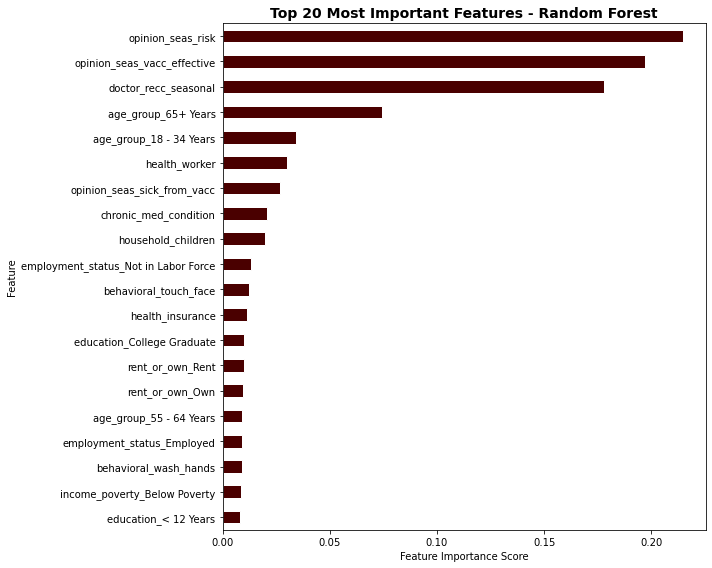

Top 10 Most Important Features
  opinion_seas_risk                             : 0.2146
  opinion_seas_vacc_effective                   : 0.1971
  doctor_recc_seasonal                          : 0.1780
  age_group_65+ Years                           : 0.0742
  age_group_18 - 34 Years                       : 0.0342
  health_worker                                 : 0.0301
  opinion_seas_sick_from_vacc                   : 0.0267
  chronic_med_condition                         : 0.0205
  household_children                            : 0.0197
  employment_status_Not in Labor Force          : 0.0134


In [22]:
#Feature Importance of our best model: Random Forest

# Get feature names after preprocessing
numeric_feature_names = numeric_features

# Get categorical feature names after one hot encoding
categorical_feature_names = preprocessor\
    .named_transformers_["categorical"]\
    .named_steps["encoder"]\
    .get_feature_names(categorical_features)\
    .tolist()

# Combine all feature names
all_feature_names = numeric_feature_names + categorical_feature_names

# Get feature importances from random forest
rf_classifier = rf_best_pipeline.named_steps["classifier"]
feature_importances = pd.Series(
    rf_classifier.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

# Plot top 20 most important features
fig, ax = plt.subplots(figsize=(10, 8))

feature_importances.head(20).sort_values().plot(
    kind="barh",
    color="#4A0000",
    edgecolor="white",
    ax=ax
)

ax.set_title(
    "Top 20 Most Important Features - Random Forest",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Feature Importance Score")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(images_path + "feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print top 10
print("Top 10 Most Important Features")
for feat, imp in feature_importances.head(10).items():
    print(f"  {feat:<45} : {imp:.4f}")

#### **Model Limitations:**

No model is perfect and therefore it is highly ethical and important to acknolwedge the limitations of our analysis:

**Data Limitations:**

- Dataset is from the US 2009 H1N1 Flu Survey and may 
  not perfectly represent the Kenyan population
- Survey data is self-reported and may contain bias
- Dataset skews older, white and educated which limits 
  generalizability across all demographic groups
- Missing values in key columns like health_insurance 
  (45.96%) may have introduced bias in imputation

**Model Limitations:**

- Models are trained on historical data from 2009 and 
  vaccination behavior may have changed since then
- Random Forest is less interpretable than Logistic 
  Regression making it harder to explain individual 
  predictions to non-technical stakeholders this id despite it perfroming the best in tems of our metrics
- Model performance may vary across demographic subgroups
  as I did not tested for fairness across age groups 
  or income levels

**Scope Limitations:**

- We predict vaccination likelihood but cannot determine 
  causality therefore we cannot say that changing one feature 
  will definitely cause someone to vaccinate
- The model does not account for supply side factors 
  like vaccine availability and cost which are 
  particularly relevant in the Kenyan context

### **CONCLUSIONS:**

#### **Recommendations for County Director of Health**

Based on our model findings the County Director of Health 
should focus community outreach on the following:

**Priority 1 : Target Low Risk Perception Communities:**

- `opinion_seas_risk` is the strongest predictor (r = 0.390)
- Communities that perceive low risk of seasonal flu are 
  significantly less likely to vaccinate
- Outreach campaigns should emphasize the real risks of 
  seasonal flu particularly for vulnerable populations
- Use community health workers to deliver risk education 
  in low income and rural areas every flu season

**Priority 2 : Target Younger Age Groups:**

- 18-34 years: only 28.5% vaccinated vs 65+ years: 67.4%
- Youth targeted vaccination campaigns are urgently needed
- Partner with universities, workplaces and community 
  organizations to reach younger populations
- Consider mobile vaccination units at locations 
  frequented by younger demographics

**Priority 3 : Target Low Income and Uninsured Populations:**

- Below poverty: 36.3% vaccinated vs above poverty: 49.7%
- Unemployed: 30.2% vaccinated — lowest employment group
- Remove financial barriers by providing free seasonal 
  flu vaccination at public health facilities
- Increase outreach in low income neighborhoods and 
  informal settlements

**Priority 4 : Address Vaccine Misinformation:**

- Belief in vaccine effectiveness (r = 0.362) is a 
  strong predictor
- Communities with low belief in effectiveness are 
  significantly less likely to vaccinate
- Deploy targeted public education campaigns addressing 
  common myths about vaccine effectiveness
- Use trusted community leaders and health workers 
  as vaccine champions


#### **Recommendations of the County Referral Hospital CEOs(Kenyatta National Hospital and Mbagathi County Hopsital)**

Based on our model findings the County Referral Hospital 
CEO should focus clinical interventions on:

**Priority 1 : Mandate Doctor Recommendations:**

- `doctor_recc_seasonal` is the second strongest predictor 
  (r = 0.369)
- A doctor's recommendation significantly increases 
  vaccination likelihood therefore implement a clinical protocol requiring all clinicians 
  to proactively recommend seasonal flu vaccination 
  during every consultation especially for high risk patients
- Track doctor recommendation rates as a clinical 
  performance indicator

**Priority 2 : Target Patients Without Health Insurance:**

- `health_insurance` is a strong predictor (r = 0.201)
- Uninsured patients are significantly less likely to 
  vaccinate
- Offer free seasonal flu vaccination to all patients 
  regardless of insurance status
- Flag uninsured patients in the hospital system for 
  proactive outreach before each flu season

**Priority 3 : Prioritize Chronic Condition Patients:**

- `chronic_med_condition` is a strong predictor (r = 0.170)
- Patients with chronic conditions are more likely to 
  vaccinate but remain a high priority group
- Ensure all chronic condition patients are contacted 
  before each flu season with vaccination reminders
- Integrate seasonal flu vaccination into chronic 
  disease management protocols

**Priority 4 : Address Side Effect Uncertainty:**

- Patients who don't know about side effects (value 3) 
  have the lowest vaccination rate at 18.1%
- Uncertainty is a bigger barrier than actual worry
- Train clinicians to proactively address side effect 
  questions during consultations
- Provide clear written information about vaccine 
  side effects to all patients

### **IMPLEMENTATION MATRIX.**

**For Immediate Implementation:**

- Share model findings with County Director of Health 
  and County Referral Hospital CEO
- Pilot community outreach targeting identified low 
  vaccination demographic groups before next flu season
- Implement doctor recommendation protocol in 
  county referral hospitals

**For Future Research:**

- Collect Kenyan specific vaccination survey data to 
  retrain and validate the model in the local context
- Test model fairness across demographic subgroups 
  to identify where performance is weaker
- Explore additional features relevant to Kenya such 
  as county of residence, urban vs rural location 
  and distance to nearest health facility
- Investigate causal relationships between identified 
  predictors and vaccination behavior using 
  experimental or quasi-experimental methods

**For Model Improvement:**

- Collect more recent data : 2009 survey data may not 
  reflect current vaccination behavior patterns
- Explore additional ensemble methods such as 
  Gradient Boosting and Stacking
- Investigate deep learning approaches for 
  potentially improved performance
- Build a simple web application to allow health 
  workers to input patient characteristics and 
  receive vaccination likelihood predictions

### **FINAL SUMMARY:**

This project successfully built a machine learning 
classification pipeline to predict seasonal flu 
vaccination uptake using the National 2009 H1N1 
Flu Survey data.

| Item | Detail |

| **Dataset** | National 2009 H1N1 Flu Survey |

| **Target** | Seasonal flu vaccination (binary) |

| **Respondents** | 26,707 survey respondents |

| **Features used** | 21 features after dropping irrelevant columns |

| **Best Model** | **Random Forest** |

| **Best ROC AUC** | **0.8518** |

| **Primary Stakeholders** | County Director of Health and County Referral Hospital CEO |

| **Context** | Methodology adapted for Kenyan public health setting |

The findings of this project provide actionable insights 
for both community level and clinical level interventions 
to increase seasonal flu vaccination rates in Kenya. 

The model identifies opinion features, doctor recommendations 
and healthcare access as the strongest predictors of 
vaccination behavior, all of which are actionable 
targets for public health intervention